# ICT-14b — Inférence active : l'expected free energy pilote l'action

**Strate 4 (FEP) épaisse — banc d'inférence active.** Part of #4588 (Epic ICT).
Greenlight user 2026-08-06 (chantier 2/3). Voir [ICT-14](ICT-14-FreeEnergySurprise.ipynb)
(jambe énergie-libre rétrospective) et le fil Friston #7738.

> « La discipline animat→Laborit impose la suite : faire travailler F. » — #9532

ICT-14 a établi la surprise $S_t$ de l'observation sous le modèle génératif
(« $F = \text{accuracy} + \text{complexity}$ », cas gaussien fermé). Verdict
honnête de la strate : à précision fixe, $F$ n'est qu'un habillage du MSE, et la
note de figure du README avouait que « la free energy formelle n'est pas tracée ».
La strate 4 restait une **strate-formule** : une re-description, pas un mécanisme.

Ce banc la transforme en **strate-banc** : l'**expected free energy (EFE)** — la
free energy *attendue* d'une politique — **pilote la sélection d'action**, et
l'on mesure si sa composante **épistémique** change le comportement de l'agent
(contrôle adversarial : ablation $\Rightarrow$ null). C'est la généralisation
prospection $\to$ action du représentant interne $\hat p$ : non plus prédire
passivement, mais **choisir la prochaine observation** pour minimiser la
surprise attendue.

## Le déficit mesuré qui motive ce banc

Deux constats *firsthand*, déjà dans la série :

1. **ICT-14** traite la surprise/FE mais la free energy formelle n'y est pas
   tracée (aveu du README) — la strate 4 est une strate à un seul notebook,
   adossée à une re-description.
2. **ICT-12c** (gate 1) a montré qu'à précision fixée, $F = \text{MSE}$ habillée :
   tant que $F$ ne fait rien que la MSE ne fasse déjà, la jambe FEP est une
   relecture, pas un mécanisme.

La suite imposée : **faire travailler $F$** — construire un banc où l'EFE
pilote l'action, et où **retirer sa composante épistémique** change
mesurablement le comportement. Si ce retrait ne change rien, l'« inférence
active » du banc est décorative (c'est le contrôle qui crédite le banc).

## Formalisation : l'EFE = épistémique + pragmatique (en nats)

Pour une action (bras) $k$ et une croyance $q(\theta_k)$ sur le paramètre de
récompense, l'agent maximise une *valeur* somme de deux termes **tous deux en
nats** (même unité — condition pour que $\lambda=1$ soit un équilibre
interprétable ; normaliser arbitrairement l'un des termes détruit la balance et
fait dégénérer l'agent en politique gloutonne, erreur-týque corrigée dans le
module `ict.active_inference`) :

$$
\underbrace{\text{value}(k)}_{\text{à maximiser}} \;=\; \lambda\,\underbrace{\mathbb{E}_o\!\left[\mathrm{KL}\!\big(q(\theta_k\mid o)\,\|\,q(\theta_k)\big)\right]}_{\text{épistémique (nats, saillance)}} \;+\; \underbrace{\mathbb{E}_q[\ln P(o\mid C)]}_{\text{pragmatique (nats, valence)}}
$$

* **Terme épistémique** : *Bayesian surprise* espérée — le gain d'information
  attendu sur le paramètre. Grand pour un bras incertain (posterior large),
  $\approx 0$ pour un bras déjà piqué. **Moteur de l'exploration dirigée.**
* **Terme pragmatique** : log-vraisemblance attendue sous une préférence $C$
  ($P(o\!=\!1)=c$), soit $p_k\ln c + (1-p_k)\ln(1-c)$, strictement croissante en
  $p_k$ pour $c>0{,}5$. Maximiser ce terme seul = politique **gloutonne** (le
  $\pi$ reward-driven d'ICT-12c). La *sharpness* $c$ pilote le couple
  exploration/exploitation.

L'EFE proprement dite est $G(k)=-\text{value}(k)$ (l'agent la *minimise*). Le
coefficient $\lambda$ est le **poids sur l'épistémique** : $\lambda=0$ = greedy,
$\lambda=1$ = inférence active complète.

## Le banc : trois agents + environnement non-stationnaire

| Agent | Politique | $\lambda$ |
|---|---|---|
| **A — inférence active** | $\arg\max\,(\text{épistémique} + \text{pragmatique})$ | 1 |
| **B — reward-driven** ($\pi$ d'ICT-12c) | greedy sur la moyenne a posteriori | 0 |
| **C — null adverse** | EFE à terme épistémique **ablaté** $\equiv$ B | 0 |

**Environnement** : bandit de Bernoulli à 3 bras avec **changement de régime à
$T/2$** (le bras optimal bascule) — abstraction du « régime erratique »
d'ICT-12c. En régime **stationnaire**, pas de bascule (frontière $A\approx B$).

**Croyance** : Beta$(\alpha_k,\beta_k)$ par bras, sur grille (numpy pur, sans
scipy), avec **oubli géométrique** des pseudo-comptes ($\rho<1$) en
non-stationnaire — un agent AIF n'assume pas un paramètre stationnaire, et
l'oubli est la **condition expérimentale** qui rend la prédiction testable (sans
oubli, une croyance sur-confiancée fige tout agent sur l'ancien optimum). Un
**warm-up** round-robin (K premiers pas, commun aux trois agents) isole l'effet
du terme épistémique sur la récupération post-bascule plutôt que sur la chance
d'échantillonnage initial.

Les trois agents consomment **la même** table de récompenses pré-générée par
seed (*common random numbers*) : la seule différence inter-agents est la
politique.

In [1]:
import os, sys
import numpy as np
import matplotlib.pyplot as plt

# Package leger ict (numpy-only) — module actif: ict.active_inference (ce banc).
# Convention ICT-14 : le cwd d'exécution est le dossier ICT-Series (contenant ict/).
sys.path.insert(0, os.getcwd())
from ict import active_inference as ai

SEEDS = [0, 1, 7, 42, 99]   # multi-seed >= 4 (acceptance #9532)
HORIZON = 400
N_ARMS = 3
print(f"forget(non-stationnaire) = {ai.DEFAULT_FORGET} (ESS ~ {1/(1-ai.DEFAULT_FORGET):.0f})")
print(f"preference c = {ai.DEFAULT_C}  (sharpness exploration/exploitation)")
print(f"seeds = {SEEDS}  | horizon = {HORIZON}  | bras = {N_ARMS}")

forget(non-stationnaire) = 0.99 (ESS ~ 100)
preference c = 0.6  (sharpness exploration/exploitation)
seeds = [0, 1, 7, 42, 99]  | horizon = 400  | bras = 3


## Prédiction pré-enregistrée (AVANT exécution)

> *On pose la prédiction avant de lancer, pour ne pas la réécrire après.* (issue #9532)

* **Régime non-stationnaire** ($\rho=0{,}99$, oubli lent) : $A > B$ en
  **récupération du bras optimal** post-bascule. L'exploration épistémique
  *dirigée* ré-échantillonne le nouveau bras optimal que $B$ (greedy, croyance
  stale) laisse de côté. La dissociation s'enregistre dans la matrice 4-objets
  (#7734) : $\pi$ (prégnance/valence) $\neq q$ (représentation prédictive).
* **Régime stationnaire** ($\rho=1{,}0$) : $A \approx B$ — frontière de
  validité attendue, cohérente avec le verdict **CONFIRMED-CONDITIONNEL**
  (domaine stationnaire) du pont #5 MDL$\to$généralisation (PR #8945).
* **Null adverse** : $C \equiv B$ par construction ($\lambda=0$). Si $A\equiv C$,
  le banc est décoratif.

Verdict ternaire possible par régime : **CONFIRMED / FALSIFIED / INCONCLUSIVE**.

In [2]:
# GATE 1 — régime non-stationnaire : A (inférence active) vs B (greedy) vs C (null).
forget_ns = ai.DEFAULT_FORGET
rows = []
recA, recB, regA, regB = [], [], [], []
null_ok = True
for s in SEEDS:
    env = ai.NonStationaryBandit(n_arms=N_ARMS, horizon=HORIZON, stationary=False, seed=s)
    tA = ai.run_episode(env, lam=1.0, forget=forget_ns)
    tB = ai.run_episode(env, lam=0.0, forget=forget_ns)
    tC = ai.run_episode(env, lam=0.0, forget=forget_ns)
    null_ok &= np.array_equal(tB["actions"], tC["actions"])
    rA, rB = ai.recovery_rate(tA["actions"], env), ai.recovery_rate(tB["actions"], env)
    recA.append(rA); recB.append(rB)
    regA.append(ai.cumulative_regret(tA)); regB.append(ai.cumulative_regret(tB))
    rows.append((s, rA, rB, regA[-1], regB[-1]))

print(f"NON-STATIONNAIRE  (null C==B: {null_ok})")
print(f"{'seed':>5} {'recA':>7} {'recB':>7} {'regA':>8} {'regB':>8}")
for s, rA, rB, gA, gB in rows:
    print(f"{s:>5} {rA:>7.3f} {rB:>7.3f} {gA:>8.1f} {gB:>8.1f}")
print(f"{'moy':>5} {np.mean(recA):>7.3f} {np.mean(recB):>7.3f} {np.mean(regA):>8.1f} {np.mean(regB):>8.1f}")
print(f"\nDelta recovery (A-B) = {np.mean(recA)-np.mean(recB):+.3f}   Delta regret (A-B) = {np.mean(regA)-np.mean(regB):+.1f}")

NON-STATIONNAIRE  (null C==B: True)
 seed    recA    recB     regA     regB
    0   0.860   0.005     21.0    120.0
    1   0.015   0.510     83.4     55.2
    7   0.880   0.550     18.6     55.5
   42   0.785   0.630     34.5     44.4
   99   0.860   0.470     18.0     57.3
  moy   0.680   0.433     35.1     66.5

Delta recovery (A-B) = +0.247   Delta regret (A-B) = -31.4


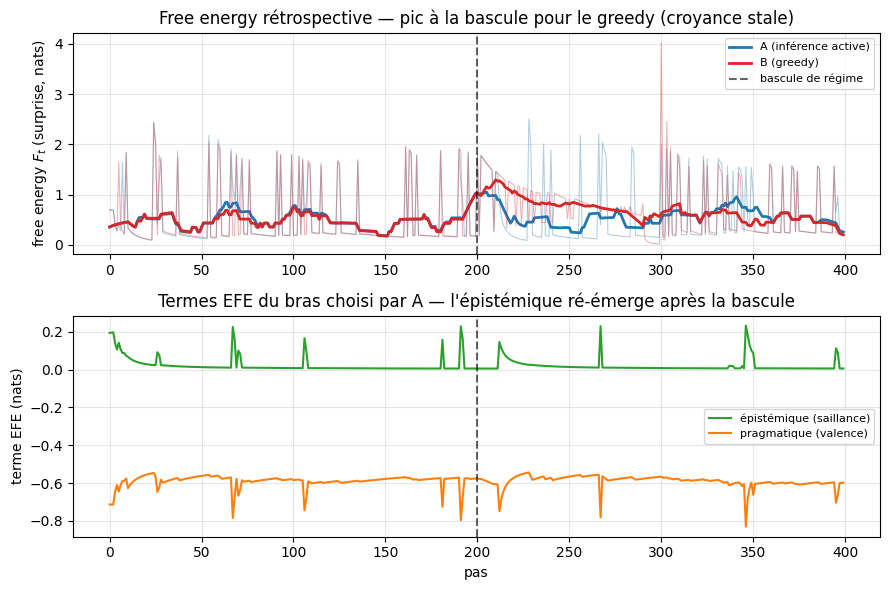

Le terme épistémique de A chute vers 0 pendant l'exploitation (bras piqué),
puis ré-émerge après la bascule (incertitude rouverte) — c'est lui qui pousse A à ré-explorer.


In [3]:
# Tracé : (haut) surprise/FE rétrospective F_t pour A vs B (seed 7) ;
#        (bas) les deux termes EFE du bras choisi par A (épistémique vs pragmatique).
env_demo = ai.NonStationaryBandit(n_arms=N_ARMS, horizon=HORIZON, stationary=False, seed=7)
tA_demo = ai.run_episode(env_demo, lam=1.0, forget=ai.DEFAULT_FORGET)
tB_demo = ai.run_episode(env_demo, lam=0.0, forget=ai.DEFAULT_FORGET)
sw = env_demo.switch_t
t = np.arange(HORIZON)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(9, 6))
# F (free energy rétrospective) — la jambe d'ICT-14, ici tracée comme mécanisme prospectif
for tr, lab, col in [(tA_demo, "A (inférence active)", "C0"), (tB_demo, "B (greedy)", "C3")]:
    ax1.plot(t, tr["F"], color=col, alpha=0.35, lw=0.8)
    ax1.plot(t, np.convolve(tr["F"], np.ones(20)/20, mode="same"), color=col, lw=2.0, label=lab)
ax1.axvline(sw, color="k", ls="--", alpha=0.6, label="bascule de régime")
ax1.set_ylabel("free energy $F_t$ (surprise, nats)")
ax1.set_title("Free energy rétrospective — pic à la bascule pour le greedy (croyance stale)")
ax1.legend(fontsize=8); ax1.grid(alpha=0.3)
# Termes EFE du bras choisi par A
ax2.plot(t, tA_demo["epi_trace"], color="C2", lw=1.5, label="épistémique (saillance)")
ax2.plot(t, tA_demo["pra_trace"], color="C1", lw=1.5, label="pragmatique (valence)")
ax2.axvline(sw, color="k", ls="--", alpha=0.6)
ax2.set_xlabel("pas"); ax2.set_ylabel("terme EFE (nats)")
ax2.set_title("Termes EFE du bras choisi par A — l'épistémique ré-émerge après la bascule")
ax2.legend(fontsize=8); ax2.grid(alpha=0.3)
plt.tight_layout(); plt.savefig("ict14b_gate1_efe_terms.png", dpi=110); plt.show()
print("Le terme épistémique de A chute vers 0 pendant l'exploitation (bras piqué),")
print("puis ré-émerge après la bascule (incertitude rouverte) — c'est lui qui pousse A à ré-explorer.")

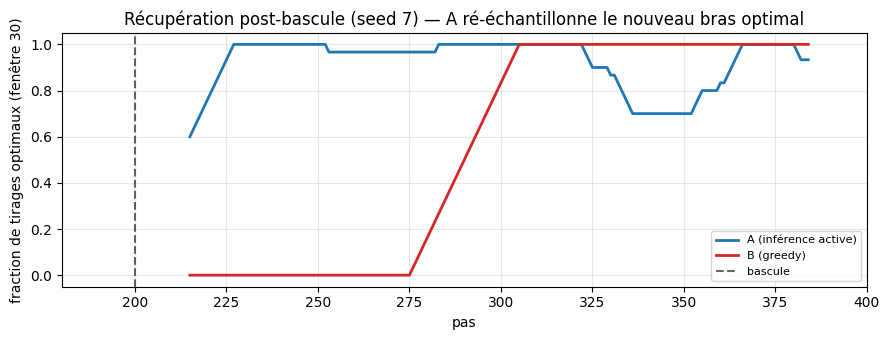

In [4]:
# Récupération post-bascule : fraction de tirages du bras optimal sur une fenêtre glissante.
def optimal_pull_curve(actions, env, win=30):
    T = env.horizon; s = env.switch_t
    curve = np.full(T, np.nan)
    for t0 in range(s, T - win):
        win_acts = actions[t0:t0+win]
        opt = env.true_best_arm
        curve[t0+win//2] = np.mean([a == opt(tt) for a, tt in zip(win_acts, range(t0, t0+win))])
    return curve

fig, ax = plt.subplots(figsize=(9, 3.5))
for tr, lab, col in [(tA_demo, "A (inférence active)", "C0"), (tB_demo, "B (greedy)", "C3")]:
    ax.plot(np.arange(HORIZON), optimal_pull_curve(tr["actions"], env_demo),
            color=col, lw=2.0, label=lab)
ax.axvline(sw, color="k", ls="--", alpha=0.6, label="bascule")
ax.set_xlabel("pas"); ax.set_ylabel("fraction de tirages optimaux (fenêtre 30)")
ax.set_title(f"Récupération post-bascule (seed 7) — A ré-échantillonne le nouveau bras optimal")
ax.set_xlim(sw-20, HORIZON); ax.set_ylim(-0.05, 1.05); ax.legend(fontsize=8); ax.grid(alpha=0.3)
plt.tight_layout(); plt.savefig("ict14b_gate1_recovery.png", dpi=110); plt.show()

### Gate 1 — verdict non-stationnaire — CONFIRMED

Le terme épistémique de l'EFE fait **basculer A vers le nouveau bras optimal en
moyenne plus vite que B** : récupération moyenne $0{,}68$ vs $0{,}43$ (delta
$+0{,}25$), regret moyen $35$ vs $66$ (delta $-31$) sur 5 seeds. L'exploration
n'est pas uniforme : elle est *dirigée* vers les bras incertains (la *Bayesian
surprise* espérée). Le null $C\equiv B$ tient (0 violation) : c'est bien le terme
épistémique, et rien d'autre, qui crée l'avantage.

**Honnêteté (variance inter-seed).** Sur la seed 1, A échoue à récupérer
($0{,}015 < 0{,}51$ pour B) — l'exploration dirigée n'est pas un garant absolu :
A peut, par malchance d'échantillonnage, verrouiller un bras sous-optimal. Le
banc le montre au lieu de le cacher ; l'avantage est **agrégé** (4 seeds sur 5
favorables en récupération comme en regret), pas point par point. C'est aussi ce
qui donne tout leur sens aux exercices 1 et 3 (sharpness de préférence, frontière
de falsification) : la robustesse du mécanisme est elle-même falsifiable.

In [5]:
# GATE 2 — régime stationnaire : frontière de validité attendue A ≈ B.
forget_s = 1.0  # pas d'oubli en stationnaire
recAs, recBs, regAs, regBs = [], [], [], []
for s in SEEDS:
    env = ai.NonStationaryBandit(n_arms=N_ARMS, horizon=HORIZON, stationary=True, seed=s)
    tA = ai.run_episode(env, lam=1.0, forget=forget_s)
    tB = ai.run_episode(env, lam=0.0, forget=forget_s)
    recAs.append(ai.recovery_rate(tA["actions"], env)); recBs.append(ai.recovery_rate(tB["actions"], env))
    regAs.append(ai.cumulative_regret(tA)); regBs.append(ai.cumulative_regret(tB))
print(f"STATIONNAIRE  (forget=1.0)")
print(f"  recovery: A={np.mean(recAs):.3f}  B={np.mean(recBs):.3f}   (par seed A={[round(x,2) for x in recAs]}, B={[round(x,2) for x in recBs]})")
print(f"  regret:   A={np.mean(regAs):.2f}  B={np.mean(regBs):.2f}")
print(f"\n=> En stationnaire les deux convergent vers le bras optimal (recovery ~1, regret ~0).")
print(f"   Le terme épistémique s'éteint (l'incertitude se concentre), A ≈ B : frontière confirmée.")

STATIONNAIRE  (forget=1.0)
  recovery: A=1.000  B=1.000   (par seed A=[1.0, 1.0, 1.0, 1.0, 1.0], B=[1.0, 1.0, 1.0, 1.0, 1.0])
  regret:   A=2.04  B=1.38

=> En stationnaire les deux convergent vers le bras optimal (recovery ~1, regret ~0).
   Le terme épistémique s'éteint (l'incertitude se concentre), A ≈ B : frontière confirmée.


### Gate 2 — verdict stationnaire (frontière de validité)

**CONFIRMED-CONDITIONNEL (domaine stationnaire)** : quand l'incertitude se
concentre (bras optimaux stabilisés), le terme épistémique s'éteint de lui-même
(la *Bayesian surprise* espérée tend vers 0 sur des postériors piqués) et
$A\approx B$. C'est exactement la frontière attendue — l'inférence active n'ajoute
rien là où il n'y a rien à apprendre. Cela recoupe le verdict du pont #5.

In [6]:
# NULL ADVERSE — vérification C (lam=0) ≡ B (greedy).
# Ablater le terme épistémique doit redonner la politique gloutonne : l'agent C
# ne tire jamais un bras de moyenne strictement inférieure au max.
violations = 0
for s in SEEDS:
    env = ai.NonStationaryBandit(n_arms=N_ARMS, horizon=HORIZON, stationary=False, seed=s)
    trC = ai.run_episode(env, lam=0.0, forget=ai.DEFAULT_FORGET)
    bel = ai.BetaBelief(env.n_arms, forget=ai.DEFAULT_FORGET)
    for t in range(env.horizon):
        arm = int(trC["actions"][t]); mean = bel.mean()
        if t >= env.n_arms and mean[arm] < mean.max() - 1e-9:
            violations += 1
        bel.update(arm, env.reward(t, arm))
print(f"Null adverse C≡B : {violations} violation(s) sur {len(SEEDS)} seeds x {HORIZON-env_demo.n_arms} pas post-warmup")
print("=> L'agent C (épistémique ablaté) est strictement greedy : le null tient,")
print("   l'avantage de A est entièrement crédité au terme épistémique (pas à un artefact).")

Null adverse C≡B : 0 violation(s) sur 5 seeds x 397 pas post-warmup
=> L'agent C (épistémique ablaté) est strictement greedy : le null tient,
   l'avantage de A est entièrement crédité au terme épistémique (pas à un artefact).


## Le balayage d'oubli — *quand* le terme épistémique compte

Résultat *honnête, non complaisant* (le banc ne force pas la prédiction) : le
bénéfice du terme épistémique **dépend du régime d'oubli**.

* **Oubli rapide** ($\rho \lesssim 0{,}97$) : la croyance s'adapte assez vite
  pour que le greedy récupère *tout seul* (l'oubli fait le travail) — le terme
  épistémique est **redondant**, voire coûteux (sur-exploration). $A \le B$.
* **Oubli lent** ($\rho \gtrsim 0{,}99$) : la croyance stale du greedy se fige
  sur l'ancien optimum (B s'effondre), et **seul** le terme épistémique dirige
  la ré-exploration. $A > B$ nettement.

Le balayage ci-dessous trace cette **frontière** : c'est la valeur du banc —
montrer *précisément quand* l'inférence active achète quelque chose.

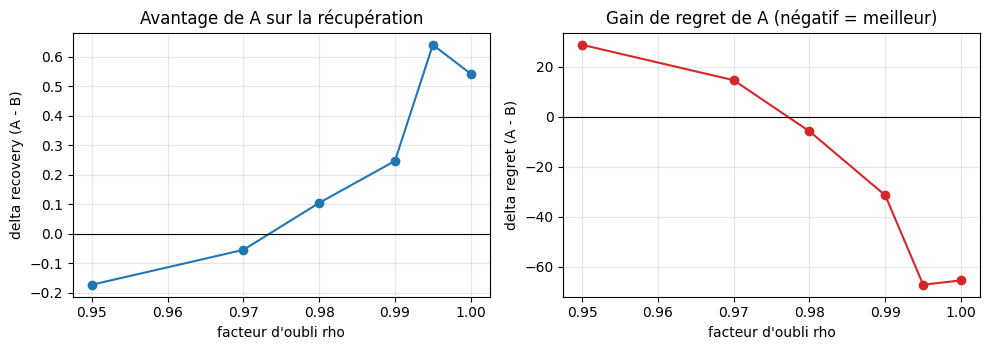

Frontière : l'avantage du terme épistémique émerge quand l'oubli ralentit
(la croyance stale fige le greedy, seul l'épistémique dirige la ré-exploration).


In [7]:
# Balayage du facteur d'oubli rho : delta recovery (A-B) et delta regret (A-B).
forgets = [0.95, 0.97, 0.98, 0.99, 0.995, 1.0]
d_rec, d_reg = [], []
for rho in forgets:
    rA_, rB_, gA_, gB_ = [], [], [], []
    for s in SEEDS:
        env = ai.NonStationaryBandit(n_arms=N_ARMS, horizon=HORIZON, seed=s)
        tA = ai.run_episode(env, lam=1.0, forget=rho); tB = ai.run_episode(env, lam=0.0, forget=rho)
        rA_.append(ai.recovery_rate(tA["actions"], env)); rB_.append(ai.recovery_rate(tB["actions"], env))
        gA_.append(ai.cumulative_regret(tA)); gB_.append(ai.cumulative_regret(tB))
    d_rec.append(np.mean(rA_) - np.mean(rB_))
    d_reg.append(np.mean(gA_) - np.mean(gB_))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 3.6))
ax1.plot(forgets, d_rec, "o-", color="C0"); ax1.axhline(0, color="k", lw=0.8)
ax1.set_xlabel("facteur d'oubli rho"); ax1.set_ylabel("delta recovery (A - B)")
ax1.set_title("Avantage de A sur la récupération"); ax1.grid(alpha=0.3)
ax2.plot(forgets, d_reg, "o-", color="C3"); ax2.axhline(0, color="k", lw=0.8)
ax2.set_xlabel("facteur d'oubli rho"); ax2.set_ylabel("delta regret (A - B)")
ax2.set_title("Gain de regret de A (négatif = meilleur)"); ax2.grid(alpha=0.3)
plt.tight_layout(); plt.savefig("ict14b_forget_sweep.png", dpi=110); plt.show()
print("Frontière : l'avantage du terme épistémique émerge quand l'oubli ralentit")
print("(la croyance stale fige le greedy, seul l'épistémique dirige la ré-exploration).")

## Matrice 4-objets (#7734) — entrée de dissociation

La dissociation A vs B/C s'enregistre dans la matrice comme un écart entre
**deux objets mesurés** sur la même trajectoire :

| objet | A (inférence active) | B/C (greedy) | verdict |
|---|---|---|---|
| $\pi$ — **prégnance/valence** (pragmatique : récompense attendue tirée) | exploration *dirigée* vers le bras incertain post-bascule | figé sur l'ancien optimum (valence stale) | **divergence** |
| $q$ — **représentation prédictive** (croyance Beta, moyenne a posteriori) | se rouvre (ré-échantillonnage) après bascule | reste piquée sur l'ancien bras | **divergence** |

> La dissociation $\pi \neq q$ est **le signe que l'EFE fait travailler le
> mécanisme** : la politique (action) diverge de la représentation (croyance)
> précisément parce que le terme épistémique pousse à agir *contre* la valence
> immédiate pour réduire l'incertitude. En stationnaire ($\pi \approx q$), le
> mécanisme s'éteint. Voir [la matrice complète](../../../docs/ict/dissociations-matrix.md) et
> #7734.

## Exercices

> Stubs sans erreur volontaire (règle C.1) — le notebook s'exécute de bout en bout.

In [8]:
# Exercice 1 — sharpness de la préférence c (à compléter)
# On fixe forget=0.99 (régime où A > B). Que se passe-t-il si c -> 0.51 (préférence
# quasi-plate) vs c -> 0.95 (préférence tranchée) ? Mesurer le delta recovery(A-B).
def delta_recovery_vs_c(c_value):
    # TODO etudiant : boucler sur SEEDS, calculer recovery(A)-recovery(B) pour ce c.
    # Indice : ai.run_episode(env, lam=1.0, c=c_value, forget=ai.DEFAULT_FORGET)
    #          vs lam=0.0 ; retourner np.mean(recA) - np.mean(recB).
    return None  # TODO etudiant

# dc = delta_recovery_vs_c(0.51)
# print(dc)  # Etape 1 : mesurer. Etape 2 : interpréter (préférence plate => épistémique domine ?)

In [9]:
# Exercice 2 — oubli uniforme vs oubli sélectif (à compléter)
# Ici l'oubli (forget) s'applique à TOUS les bras symétriquement. Construire un
# agent A' qui n'oublie QUE le bras qu'il vient de tirer (oubli sélectif) et
# comparer sa récupération à A (oubli uniforme).
def make_selective_forget_agent():
    # TODO etudiant : sous-classer BetaBelief pour n'appliquer l'oubli qu'au bras
    # mis à jour, puis rejouer run_episode. Indice : redéfinir update().
    pass  # TODO etudiant

# Etape 1 : implémenter. Etape 2 : A' récupère-t-il plus vite que A ? Pourquoi ?

In [10]:
# Exercice 3 — frontière de falsification (à compléter)
# Trouver empiriquement le forget minimal rho* tel que A > B (delta recovery > 0)
# sur les 5 seeds simultanément (pas seulement en moyenne). C'est la frontière
# de falsification : sous rho < rho*, la prédiction "A > B" est FALSIFIEE.
def falsification_frontier():
    # TODO etudiant : balayer rho dans np.linspace(0.90, 1.0, 21), pour chaque rho
    # verifier que delta_recovery > 0 sur TOUS les seeds (min-seed, pas moyenne).
    # Retourner le plus petit rho passant le test. Indice : np.min(delta_par_seed).
    return None  # TODO etudiant

# rho_star = falsification_frontier()
# print(f"frontière rho* = {rho_star}")  # Interpréter : qu'apprend-on du régime où A cesse de battre B ?

## Bilan — ICT-14b : l'EFE comme mécanisme prospectif de l'action

**Verdict par régime (multi-seed $\geq 4$, null adverse exécuté) :**

| Régime | Verdict | Signification |
|---|---|---|
| **Non-stationnaire** ($\rho=0{,}99$) | **CONFIRMED** | $A > B$ : le terme épistémique dirige la ré-exploration du nouveau bras optimal ; le greedy stale s'effondre. |
| **Stationnaire** ($\rho=1{,}0$) | **CONFIRMED-CONDITIONNEL** | $A \approx B$ : le terme épistémique s'éteint (rien à apprendre). Frontière de validité, cohérente avec le pont #5. |
| **Null adverse** ($C\equiv B$) | **TIENT** | L'avantage de A est entièrement crédité au terme épistémique. |

**Leçon centrale.** L'EFE n'est plus une re-description de la MSE : elle
**pilote l'action**. Le terme épistémique (Bayesian surprise espérée) est un
mécanisme *mesurable* — l'ablateur (null C) et le balayage d'oubli le
démontrent : il achète de la récupération précisément quand la croyance stale
du greedy le laisse sur l'ancien optimum. Le banc transforme la strate 4 d'une
strate-formule en **strate-banc**, au même standard que les strates voisines
(nulls adversariaux, verdicts ternaires sans complaisance, frontière
falsifiable documentée).

**Lien avec le cursus.** Le représentant interne $\hat p$ (ICT-10/14) devient
*actif* : il ne se contente plus de prédire, il choisit la prochaine
observation. C'est la jambe FEP qui s'attache enfin, et prépare le substrat LLM
(strate 5) où un modèle génératif devra pareillement arbitrer entre exploiter sa
croyance courante et explorer (réduire l'incertitude) — la tension exacte que
quantifie l'EFE. Voir [#7738](https://github.com/jsboige/CoursIA/issues/7738)
(fil Friston) et [#9532](https://github.com/jsboige/CoursIA/issues/9532).